# SARIMAX Model

## Objective

This notebook develops a Seasonal Autoregressive Integrated Moving Average with Exogenous Variables (SARIMAX) model for forecasting weekly German electricity demand.

Calendar-based explanatory variables are incorporated into the model to capture temporal patterns beyond those represented by the seasonal autoregressive structure. Model performance is evaluated using RMSE, MAE and MAPE and compared with the benchmark and SARIMA models.

In [17]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.stats.diagnostic import acorr_ljungbox

from statsmodels.graphics.gofplots import qqplot

In [18]:
weekly_load = pd.read_csv(
    "weekly_load.csv",
    index_col=0,
    parse_dates=True
)

weekly_load.head()

,load
timestamp,
2015-01-04 00:00:00+00:00,47233.739583
2015-01-11 00:00:00+00:00,56191.101190
2015-01-18 00:00:00+00:00,57672.678571
2015-01-25 00:00:00+00:00,58613.303571
2015-02-01 00:00:00+00:00,58734.029762


In [19]:
forecast_horizon = 104

train = weekly_load.iloc[:-forecast_horizon]

test = weekly_load.iloc[-forecast_horizon:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 197
Testing observations: 104


## Feature Engineering

Calendar-based explanatory variables are generated from the timestamp to provide additional information to the SARIMAX model. Both categorical calendar features and cyclical transformations are included to better represent recurring seasonal behaviour.

In [20]:
weekly_load["month"] = weekly_load.index.month

weekly_load["quarter"] = weekly_load.index.quarter

weekly_load["week"] = weekly_load.index.isocalendar().week.astype(int)

weekly_load["year"] = weekly_load.index.year

In [21]:
weekly_load["month_sin"] = np.sin(2 * np.pi * weekly_load["month"] / 12)

weekly_load["month_cos"] = np.cos(2 * np.pi * weekly_load["month"] / 12)

weekly_load["week_sin"] = np.sin(2 * np.pi * weekly_load["week"] / 52)

weekly_load["week_cos"] = np.cos(2 * np.pi * weekly_load["week"] / 52)

In [22]:
train = weekly_load.iloc[:-forecast_horizon]

test = weekly_load.iloc[-forecast_horizon:]

feature_columns = [
    "month",
    "quarter",
    "week",
    "year",
    "month_sin",
    "month_cos",
    "week_sin",
    "week_cos"
]

exog_train = train[feature_columns]

exog_test = test[feature_columns]

## SARIMAX Model Fitting

A SARIMAX model is fitted using the optimal SARIMA parameters identified previously. Calendar-based explanatory variables are included as exogenous predictors to improve forecasting performance.

In [23]:
sarimax_model = SARIMAX(
    train["load"],
    exog=exog_train,
    order=(1, 1, 2),
    seasonal_order=(0, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_results = sarimax_model.fit(disp=False)

In [24]:
print(sarimax_results.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                 load   No. Observations:                  197
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 52)   Log Likelihood                -778.063
Date:                              Thu, 02 Jul 2026   AIC                           1582.127
Time:                                      10:47:47   BIC                           1614.479
Sample:                                  01-04-2015   HQIC                          1595.167
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
month         34.0699   1.08e+04      0.003      0.997   -2.11e+04    2.12e+04
quarter     1361.03

In [25]:
with open("sarimax_model_summary.txt", "w") as f:
    f.write(sarimax_results.summary().as_text())

## Residual Diagnostics

Residual diagnostics are performed to determine whether the fitted SARIMAX model adequately captures the temporal structure of the data. Ideally, the residuals should be randomly distributed around zero with no remaining autocorrelation.

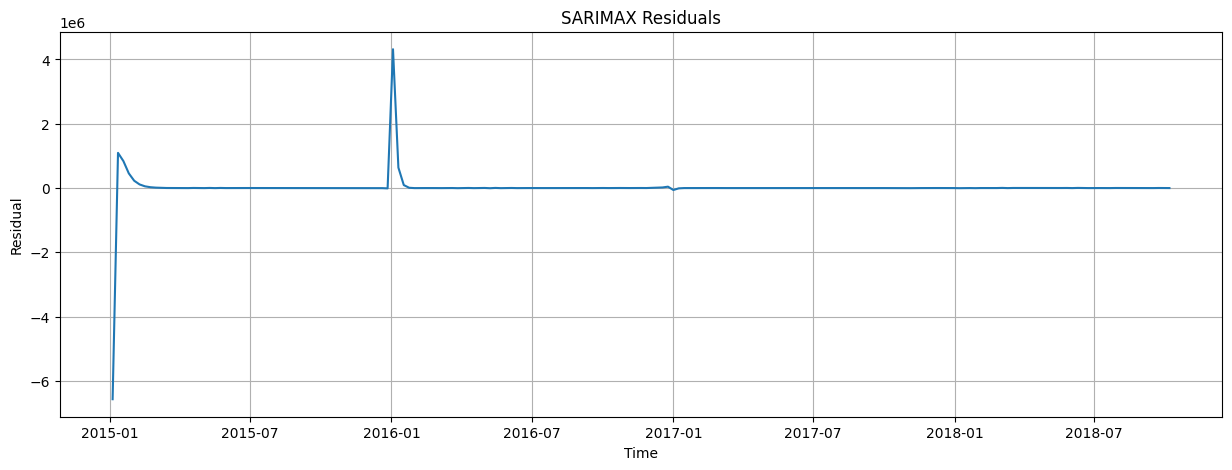

In [26]:
# Calculate residuals

residuals = sarimax_results.resid

# Plot residuals

plt.figure(figsize=(15,5))

plt.plot(residuals)

plt.title("SARIMAX Residuals")

plt.xlabel("Time")

plt.ylabel("Residual")

plt.grid(True)

plt.savefig(
    "sarimax_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

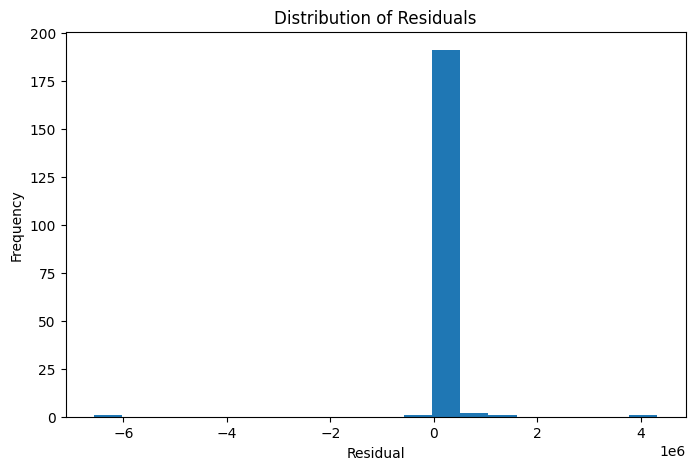

In [27]:
# Plot residual distribution

plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=20
)

plt.title("Distribution of Residuals")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.savefig(
    "sarimax_residual_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

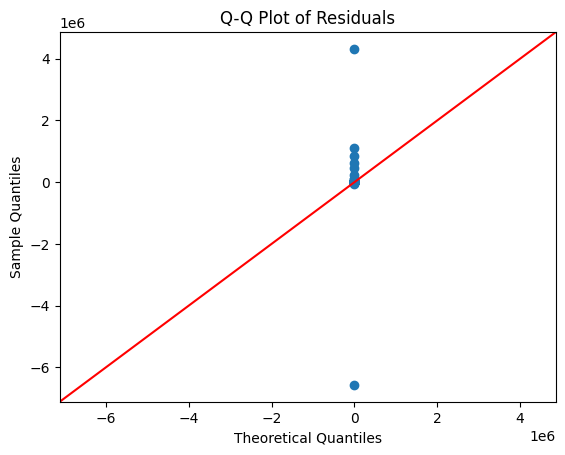

In [28]:
# Q-Q plot

qqplot(
    residuals,
    line="45"
)

plt.title("Q-Q Plot of Residuals")

plt.savefig(
    "sarimax_qq_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Ljung–Box Test

The Ljung–Box test is applied to determine whether significant autocorrelation remains in the model residuals. A p-value greater than 0.05 indicates that the residuals behave like white noise.

In [29]:
# Perform Ljung–Box test

ljung_box = acorr_ljungbox(
    residuals,
    lags=[10],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
10,1.852411,0.997351


## SARIMAX Forecasting

The fitted SARIMAX model is used to generate forecasts for the testing period. Forecasted values are compared with the observed electricity demand to assess predictive performance.

In [30]:
# Generate forecasts for the testing period

sarimax_forecast = sarimax_results.get_forecast(
    steps=len(test),
    exog=exog_test
)

forecast_mean = sarimax_forecast.predicted_mean

forecast_ci = sarimax_forecast.conf_int()

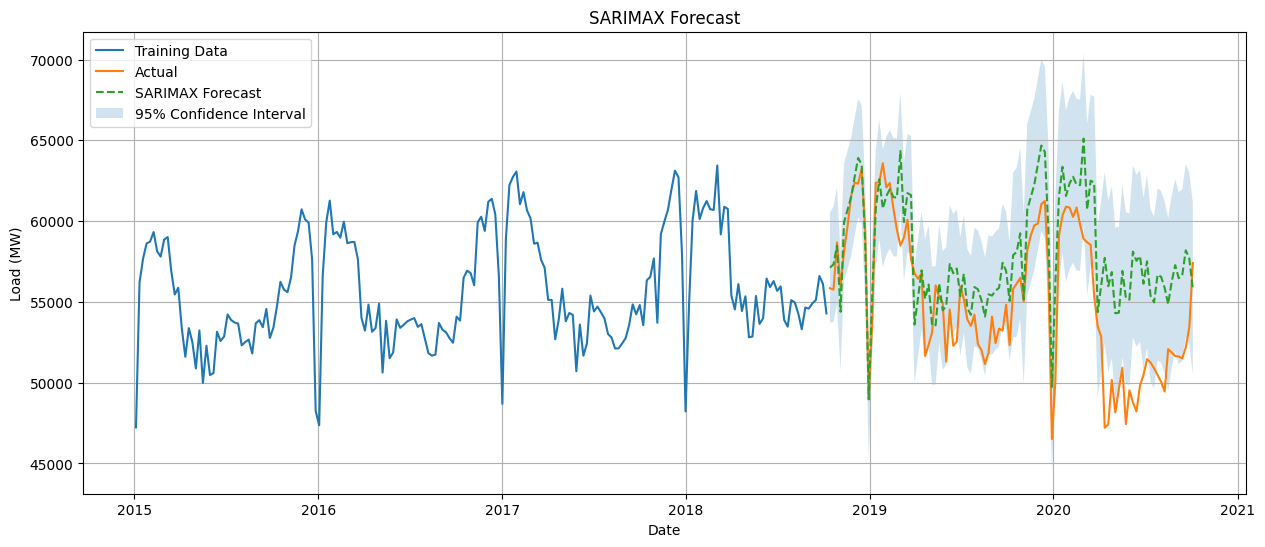

In [31]:
# Plot forecasts

plt.figure(figsize=(15,6))

plt.plot(
    train.index,
    train["load"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["load"],
    label="Actual"
)

plt.plot(
    test.index,
    forecast_mean,
    linestyle="--",
    label="SARIMAX Forecast"
)

plt.fill_between(
    test.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMAX Forecast")

plt.xlabel("Date")

plt.ylabel("Load (MW)")

plt.legend()

plt.grid(True)

plt.savefig(
    "sarimax_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Forecast Evaluation Function

A reusable evaluation function is defined to calculate three forecasting accuracy metrics: Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and Mean Absolute Percentage Error (MAPE). These metrics are used consistently across all forecasting models in this project.

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Forecast evaluation function

def evaluate_forecast(actual, forecast):
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae = mean_absolute_error(actual, forecast)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

## Forecast Evaluation

Forecast accuracy is evaluated using three commonly used error metrics:

- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- Mean Absolute Percentage Error (MAPE)

These metrics are compared with the benchmark and SARIMA models.

In [35]:
sarimax_metrics = evaluate_forecast(
    test["load"],
    forecast_mean
)

print(sarimax_metrics)

{'RMSE': np.float64(3932.842367289217), 'MAE': 3160.7449928352926, 'MAPE': np.float64(5.990058902939621)}


In [36]:
sarimax_metrics_df = pd.DataFrame(
    [sarimax_metrics]
)

sarimax_metrics_df.to_csv(
    "sarimax_metrics.csv",
    index=False
)

sarimax_metrics_df

,RMSE,MAE,MAPE
0,3932.842367,3160.744993,5.990059


In [37]:
forecast_df = pd.DataFrame({
    "Actual": test["load"],
    "Forecast": forecast_mean
})

forecast_df.to_csv(
    "sarimax_forecast.csv"
)

forecast_df.head()

,Actual,Forecast
2018-10-14 00:00:00+00:00,55848.940476,57127.070079
2018-10-21 00:00:00+00:00,55762.125000,57317.153472
2018-10-28 00:00:00+00:00,58684.714286,58474.607173
2018-11-04 00:00:00+00:00,55917.589286,54389.685989
2018-11-11 00:00:00+00:00,58163.470238,59936.302411
